# This notebook demonstrates BEEF-vdW covariances being included in the uncertainty analysis

In [1]:
import os
import rmgpy.chemkin
import copy
import rmgpy.tools.uncertainty
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Load the mechanism

In [2]:
chemkin_file = './chemkin/chem_annotated-gas.inp'
surf_chemkin_file = './chemkin/chem_annotated-surface.inp'
dict_file = './chemkin/species_dictionary.txt'

surfaceThermoPt111_uncertainty_lib = os.path.join(rmgpy.settings['database.directory'], 'thermo', 'uncertainty', 'surfaceThermoPt111')
adsorptionPt111_uncertainty_lib = os.path.join(rmgpy.settings['database.directory'], 'thermo', 'uncertainty', 'adsorptionPt111')

uncertainty = rmgpy.tools.uncertainty.Uncertainty(
    thermo_covariance_libraries=None,
    thermo_covariance_groups=None
)
uncertainty.load_model(chemkin_file, dict_file, surface_path=surf_chemkin_file)

def get_i_thing(thing, thing_list):
    for i in range(len(thing_list)):
        if thing.is_isomorphic(thing_list[i]):
            return i
    assert False

In [3]:
# Uncertainty database needs to match the input file that was used to generate the mechanism
uncertainty.load_database(
    kinetics_families=[
        'default',
        'Surface_Adsorption_Single',
        'Surface_Adsorption_vdW',
        'Surface_Adsorption_Dissociative',
        'Surface_Dissociation',
        'Surface_Abstraction',
        'Surface_Dissociation_Double_vdW',
        'Surface_Dissociation_vdW',
        'Surface_Abstraction_vdW',
        'Surface_Dissociation_Beta',
        'Surface_Adsorption_Bidentate',
        'Surface_Bidentate_Dissociation',
        'Surface_Monodentate_to_Bidentate',
        'Surface_Dissociation_to_Bidentate',
        'Surface_vdW_to_Bidentate',
        'Surface_Adsorption_Dissociative_Double',
        'Surface_Abstraction_Beta',
        'Surface_Dissociation_Double',
        'Surface_Dissociation_Beta_vdW',
        'Surface_Abstraction_Beta_vdW',
        'Surface_Abstraction_Single_vdW',
    ],
    thermo_libraries=[
        'surfaceThermoPt111',  # hard to get non-library species if you use surfaceThermoPt111
        'primaryThermoLibrary',
        'thermo_DFT_CCSDTF12_BAC',
        'DFT_QCI_thermo',
    ],
    reaction_libraries = [
        'custom_lib',
        'Surface/CPOX_Pt/Deutschmann2006_adjusted',
        'BurkeH2O2inArHe'
    ]
)

ThermoData(Tdata=([300,400,500,600,800,1000,1500],'K'), Cpdata=([60.2599,68.0494,74.7775,80.9311,90.8846,97.4337,105.393],'J/(mol*K)'), H298=(-477.191,'kJ/mol'), S298=(269.551,'J/(mol*K)'), Cp0=(33.2579,'J/(mol*K)'), CpInf=(103.931,'J/(mol*K)'), comment="""Thermo group additivity estimation: group(O2s-(Cds-Cd)(Cds-Cd)) + group(O2s-(Cds-O2d)H) + group(Cds-OdOsOs) + group(Li-OCOdO) + radical(OC=OOJ)""").
The thermo for this species is probably wrong! Setting CpInf = Cphigh for Entropy calculationat T = 2000.0 K...


ThermoData(Tdata=([300,400,500,600,800,1000,1500],'K'), Cpdata=([60.2599,68.0494,74.7775,80.9311,90.8846,97.4337,105.393],'J/(mol*K)'), H298=(-477.191,'kJ/mol'), S298=(269.551,'J/(mol*K)'), Cp0=(33.2579,'J/(mol*K)'), CpInf=(103.931,'J/(mol*K)'), comment="""Thermo group additivity estimation: group(O2s-(Cds-Cd)(Cds-Cd)) + group(O2s-(Cds-O2d)H) + group(Cds-OdOsOs) + group(Li-OCOdO) + radical(OC=OOJ)""").
The thermo for this species is probably wrong! Setting CpInf = Cphigh for Entropy calculationat T = 1666.6666666666665 K...


## Show the "before" picture:

## Even with correlations, there are hardly any off-diagonal elements in the covariance matrix

Text(0, 0.5, 'Species Index')

<Figure size 640x480 with 0 Axes>

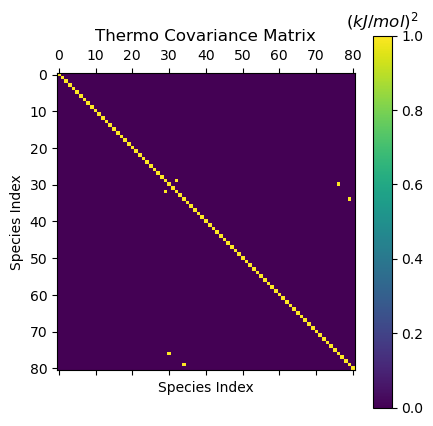

In [4]:
# save uncorrelated results
uncertainty.thermo_covariance_groups = None
uncertainty.thermo_covariance_libraries = None
uncertainty.thermo_covariances_dict = {}
uncertainty.extract_sources_from_model()
uncertainty.assign_intermediate_uncertainties(correlated=True)  # new formulation
thermo_covariance_matrix = uncertainty.get_thermo_covariance_matrix()

# basic check on the thermo covariance matrix: symmetric and positive semi-definite
assert np.allclose(thermo_covariance_matrix, thermo_covariance_matrix.T, atol=1e-8)
assert np.all(np.linalg.eigvals(thermo_covariance_matrix) >= -1e-8)  # allow for small numerical errors

plt.figure()
# Look at the covariance matrix
plt.matshow(thermo_covariance_matrix)
cb = plt.colorbar()
# plt.clim([0, (30 / 4.184) ** 2])
plt.clim([0, 1])  # zoom way in so we can see any non-zero elements
cb.ax.set_title(r'$(kJ/mol)^2$')
plt.title('Thermo Covariance Matrix')
plt.xlabel('Species Index')
plt.ylabel('Species Index')

### without BEEF correlations, library entries are uncorrelated

In [5]:
sp1 = rmgpy.species.Species(smiles='[CH2]=*')
sp2 = rmgpy.species.Species(smiles='C*')

i1 = get_i_thing(sp1, uncertainty.species_list)
i2 = get_i_thing(sp2, uncertainty.species_list)

display(i1, sp1)
display(i2, sp2)

print(f'Covariance({uncertainty.species_list[i1]}, {uncertainty.species_list[i2]}) = {thermo_covariance_matrix[i1, i2]:0.4f} (kcal/mol)^2',
     '  <-------- off diagonal is zero')

42

43

Covariance(CH2X(25), CH3X(26)) = 0.0000 (kcal/mol)^2   <-------- off diagonal is zero


### adsorption groups are also uncorrelated

76

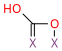

Source 1:


{'Library': 30,
 'ADS': {'adsorptionPt111': [(<Entry index=65 label="C=*RO-*">, 1)]}}

78

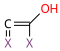

Source 2:


{'Library': 83,
 'GAV': {'radical': [(<Entry index=1797 label="Acetyl">, 1)]},
 'ADS': {'adsorptionPt111': [(<Entry index=56 label="C-*RC=*">, 1)]}}


Covariance(HOCOXX(135), C2HOX2(142)) = 0.0000 (kcal/mol)^2   <-------- different ads groups are completely uncorrelated despite overlapping DFT


In [6]:
i1 = 76
i2 = 78

display(i1, uncertainty.species_list[i1])
print('Source 1:')
display(uncertainty.species_sources_dict[uncertainty.species_list[i1]])

display(i2, uncertainty.species_list[i2])
print('Source 2:')
display(uncertainty.species_sources_dict[uncertainty.species_list[i2]])
print()
print(f'Covariance({uncertainty.species_list[i1]}, {uncertainty.species_list[i2]}) = {thermo_covariance_matrix[i1, i2]:0.4f} (kcal/mol)^2',
     '  <-------- different ads groups are completely uncorrelated despite overlapping DFT')

# Recalculate covariances with BEEF-correlations and show the "after" picture

### Now there are off-diagonal correlations for basically all the surface species because, whether from a library or the adsorption correction, they all use BEEF-vdW

Text(0, 0.5, 'Species Index')

<Figure size 640x480 with 0 Axes>

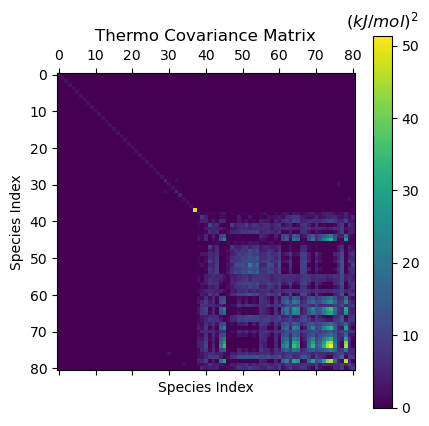

In [7]:
# save uncorrelated results
uncertainty.thermo_covariances_dict = {}
uncertainty.thermo_covariance_libraries = [surfaceThermoPt111_uncertainty_lib]
uncertainty.thermo_covariance_groups = [adsorptionPt111_uncertainty_lib]


uncertainty.extract_sources_from_model()
uncertainty.assign_intermediate_uncertainties(correlated=True)  # new formulation
thermo_covariance_matrix = uncertainty.get_thermo_covariance_matrix()

# basic check on the thermo covariance matrix: symmetric and positive semi-definite
assert np.allclose(thermo_covariance_matrix, thermo_covariance_matrix.T, atol=1e-8)
assert np.all(np.linalg.eigvals(thermo_covariance_matrix) >= -1e-8)  # allow for small numerical errors

plt.figure()
# Look at the covariance matrix
plt.matshow(thermo_covariance_matrix)
cb = plt.colorbar()
plt.clim([0, (30 / 4.184) ** 2])
# plt.clim([0, 1])  # zoom way in so we can see any non-zero elements
cb.ax.set_title(r'$(kJ/mol)^2$')
plt.title('Thermo Covariance Matrix')
plt.xlabel('Species Index')
plt.ylabel('Species Index')

### Now library entries can be correlated to each other

In [8]:
sp1 = rmgpy.species.Species(smiles='[CH2]=*')
sp2 = rmgpy.species.Species(smiles='C*')

i1 = get_i_thing(sp1, uncertainty.species_list)
i2 = get_i_thing(sp2, uncertainty.species_list)

display(i1, sp1)
display(uncertainty.species_sources_dict[uncertainty.species_list[i1]])

display(i2, sp2)
display(uncertainty.species_sources_dict[uncertainty.species_list[i2]])
print()
print(f'Covariance({uncertainty.species_list[i1]}, {uncertainty.species_list[i2]}) = {thermo_covariance_matrix[i1, i2]:0.4f} (kcal/mol)^2',
     '  <-------- off diagonal is non-zero')

42

{'Surface_Library': 42}

43

{'Surface_Library': 43}


Covariance(CH2X(25), CH3X(26)) = 4.2400 (kcal/mol)^2   <-------- off diagonal is non-zero


### Now adsorption groups can be correlated to library entries

76

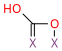

Source 1:


{'Library': 30,
 'ADS': {'adsorptionPt111': [(<Entry index=65 label="C=*RO-*">, 1)]}}

78

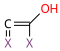

Source 2:


{'Library': 83,
 'GAV': {'radical': [(<Entry index=1797 label="Acetyl">, 1)]},
 'ADS': {'adsorptionPt111': [(<Entry index=56 label="C-*RC=*">, 1)]}}


Covariance(HOCOXX(135), C2HOX2(142)) = 5.1814 (kcal/mol)^2   <-------- different adsorption groups have non-zero covariance


In [9]:
i1 = 76
i2 = 78

display(i1, uncertainty.species_list[i1])
print('Source 1:')
display(uncertainty.species_sources_dict[uncertainty.species_list[i1]])

display(i2, uncertainty.species_list[i2])
print('Source 2:')
display(uncertainty.species_sources_dict[uncertainty.species_list[i2]])
print()
print(f'Covariance({uncertainty.species_list[i1]}, {uncertainty.species_list[i2]}) = {thermo_covariance_matrix[i1, i2]:0.4f} (kcal/mol)^2',
     '  <-------- different adsorption groups have non-zero covariance')

### Now adsorption groups can be correlated to each other

76

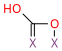

Source 1:


{'Library': 30,
 'ADS': {'adsorptionPt111': [(<Entry index=65 label="C=*RO-*">, 1)]}}

77

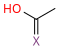

Source 2:


{'Surface_Library': 77}


Covariance(HOCOXX(135), CH3XCOH(140)) = 10.0169 (kcal/mol)^2   <-------- adsorption group is correlated to library entry. Notice the similar structures.


In [10]:
i1 = 76
i2 = 77

display(i1, uncertainty.species_list[i1])
print('Source 1:')
display(uncertainty.species_sources_dict[uncertainty.species_list[i1]])

display(i2, uncertainty.species_list[i2])
print('Source 2:')
display(uncertainty.species_sources_dict[uncertainty.species_list[i2]])
print()
print(f'Covariance({uncertainty.species_list[i1]}, {uncertainty.species_list[i2]}) = {thermo_covariance_matrix[i1, i2]:0.4f} (kcal/mol)^2',
     '  <-------- adsorption group is correlated to library entry. Notice the similar structures.')

# Do local analysis to see that covariances can be computed in reasonable time.

### Run sensitivity (this took me ~30 seconds)

In [11]:
temperature = (2000,'K')
initial_pressure = (1.0, 'bar')
termination_time = (1.0e-7, 's')

CH4 = uncertainty.species_list[get_i_thing(rmgpy.species.Species(smiles='C'), uncertainty.species_list)]
O2 = uncertainty.species_list[get_i_thing(rmgpy.species.Species(smiles='[O][O]'), uncertainty.species_list)]
Ar = uncertainty.species_list[get_i_thing(rmgpy.species.Species(smiles='[Ar]'), uncertainty.species_list)]
X = uncertainty.species_list[get_i_thing(rmgpy.species.Species(smiles='*'), uncertainty.species_list)]
CO2X = uncertainty.species_list[get_i_thing(rmgpy.species.Species(smiles='O=C=O.*'), uncertainty.species_list)]

initial_mole_fractions = {
    CH4: 0.041866,
    O2: 0.03488,
    Ar: 0.131246,
}

initialSurfaceCoverages={
    X: 1.0,
}
surfaceVolumeRatio=(1.e1, 'm^-1')
                                    

sensitive_species = [CO2X]

uncertainty.sensitivity_analysis(
    initial_mole_fractions = initial_mole_fractions,
    initial_surface_coverages=initialSurfaceCoverages,
    sensitive_species=sensitive_species,
    T=temperature,
    P=initial_pressure,
    termination_time=termination_time,
    surface_volume_ratio=surfaceVolumeRatio
)
    
    

In [12]:
results = uncertainty.local_analysis_intermediate(sensitive_species=[CO2X], correlated=True)

In [13]:
total_variance, reaction_uncertainty, thermo_uncertainty = results[CO2X]

In [14]:
processed_results, output = rmgpy.tools.uncertainty.process_local_results(results, sensitive_species=[CO2X])

In [15]:
print(output)

Total variance [(d ln(c))^2] for species CO2X is 3487.774411
--------------------------------------------------------------------------------
Top 10 reaction rate contributors                              Sensitivity Index
--------------------------------------------------------------------------------
Surface_Library X(1)+X(1)+O2(3)<=>OX(24)+OX(24)                         29.8879%
Surface_Library X(1)+CO2(4)<=>CO2X(22)                                  20.2053%
Surface Rate Rule Surface_Bidentate_Dissociation Combined               11.2634%
Surface Rate Rule Surface_Dissociation_Beta O-H;VacantSite               9.0564%
Surface Rate Rule Surface_Adsorption_Single N=O;VacantSite               2.5747%
Estimation Family HOCOXX(135)<=>OX(24)+XCOH(88)                          1.5931%
Estimation Family X(1)+XCOH(88)<=>HX(21)+COX(23)                         1.2791%
Surface Rate Rule Surface_Abstraction_Beta O;R-O-H                       1.1000%
Surface_Library X(1)+X(1)+H2(6)<=>HX(21)+HX(21) 